# Urban Validation — Global Metrics Aggregation

Reads per-city **vector** and **raster** summary parquets from `outputs/metrics/<city>/`,
aggregates to global-level metrics, and writes outputs to `outputs/global_metrics/`.

**Outputs (parquet + csv pairs)**
- `vector_all_cities_merged`  — all rows, all cities, vector pipeline
- `vector_global_summary_by_dataset` — one row per vector dataset
- `vector_detail_by_city_dataset` — full detail (city × dataset), vector
- `vector_best_dataset_per_city` — best vector dataset per city by F1
- `raster_all_cities_merged`  — all rows, all cities, raster pipeline
- `raster_global_summary_by_dataset` — one row per raster dataset
- `raster_detail_by_city_dataset` — full detail (city × dataset), raster
- `raster_best_dataset_per_city` — best raster dataset per city by F1

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [4]:
ROOT_DIR = Path("/content/drive/MyDrive/Gates Foundation/Building Dataset Validation/outputs/metrics")
OUT_DIR = Path("/content/drive/MyDrive/Gates Foundation/Building Dataset Validation/outputs/global_metrics")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Vector column config ──────────────────────────────────────────────────────
VECTOR_SUMMARY_FILE = "vector_city_summary_all_datasets.parquet"
VECTOR_SUMMARY_CSV  = "vector_city_summary_all_datasets.csv"   # fallback

VECTOR_WEIGHTED_MEAN_COLS = [
    "precision_city",
    "recall_city",
    "f1_city",
    "iou_mean_tp",
    "iou_median_tp",
    "iou_p25_tp",
    "iou_p75_tp",
    "boundary_f_meanpair_tp",
    "rel_area_error_mean_tp",
    "rel_area_error_median_tp",
    "signed_area_bias_tp",
]
VECTOR_SUM_COLS = [
    "n_sub_areas",
    "n_tiles",
    "n_ref_total",
    "n_cand_total",
    "tp_total",
    "fp_total",
    "fn_total",
]

# ── Raster column config ──────────────────────────────────────────────────────
RASTER_SUMMARY_FILE = "raster_city_summary_all_datasets.parquet"

RASTER_WEIGHTED_MEAN_COLS = [
    "precision_area",
    "recall_area",
    "f1_area",
    "tile_f1_mean",
    "tile_f1_median",
    "tile_f1_p25",
    "tile_f1_p75",
    "rel_area_error_mean",
    "rel_area_error_median",
    "quantity_disagreement_mean",
    "allocation_disagreement_mean",
]
RASTER_SUM_COLS = [
    "n_tiles",
    "tp_m2",
    "fp_m2",
    "fn_m2",
    "valid_area_total_m2",
    "signed_area_bias_total_m2",
]

In [5]:
# ── Loader helpers ─────────────────────────────────────────────────────────────

def load_vector_cities(root: Path) -> pd.DataFrame:
    """Walk root/<CITY>/ and load vector city summary parquets (CSV fallback)."""
    frames, missing = [], []
    for city_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        pq_path  = city_dir / VECTOR_SUMMARY_FILE
        csv_path = city_dir / VECTOR_SUMMARY_CSV
        if pq_path.exists():
            df = pd.read_parquet(pq_path)
        elif csv_path.exists():
            df = pd.read_csv(csv_path)
        else:
            missing.append(city_dir.name)
            continue
        df["city"] = city_dir.name
        frames.append(df)
        print(f"  [V-OK]   {city_dir.name:35s}  ({len(df)} rows)")

    if missing:
        print(f"\n  [WARN] No vector summary for: {missing}")
    if not frames:
        raise RuntimeError("No vector city summaries found.")
    merged = pd.concat(frames, ignore_index=True)
    print(f"\n  → {len(frames)} cities | {len(merged)} rows")
    return merged


def load_raster_cities(root: Path) -> pd.DataFrame:
    """Walk root/<CITY>/ and load raster city summary parquets."""
    frames, missing = [], []
    for city_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        pq_path = city_dir / RASTER_SUMMARY_FILE
        if not pq_path.exists():
            missing.append(city_dir.name)
            continue
        df = pd.read_parquet(pq_path)
        # city column may already be present from the raster pipeline
        if "city" not in df.columns:
            df["city"] = city_dir.name
        frames.append(df)
        print(f"  [R-OK]   {city_dir.name:35s}  ({len(df)} rows)")

    if missing:
        print(f"\n  [WARN] No raster summary for: {missing}")
    if not frames:
        raise RuntimeError("No raster city summaries found.")
    merged = pd.concat(frames, ignore_index=True)
    print(f"\n  → {len(frames)} cities | {len(merged)} rows")
    return merged


# ── Aggregation helpers ────────────────────────────────────────────────────────

def weighted_mean(group: pd.DataFrame, cols: list, weight_col: str) -> pd.Series:
    w = group[weight_col].fillna(0)
    result = {}
    for col in cols:
        if col in group.columns and w.sum() > 0:
            result[col] = (group[col].fillna(0) * w).sum() / w.sum()
        else:
            result[col] = float("nan")
    return pd.Series(result)


def aggregate_vector_by_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """One row per vector dataset: counts summed, metrics weighted by n_ref_total."""
    rows = []
    for dataset, grp in df.groupby("dataset"):
        row = {"dataset": dataset, "n_cities": grp["city"].nunique()}
        for col in VECTOR_SUM_COLS:
            if col in grp.columns:
                row[col] = grp[col].sum()
        # Re-derive P/R/F1 from global TP+FP+FN
        tp, fp, fn = row.get("tp_total", 0), row.get("fp_total", 0), row.get("fn_total", 0)
        row["precision_global"] = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        row["recall_global"]    = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        p, r = row["precision_global"], row["recall_global"]
        row["f1_global"] = (2 * p * r / (p + r)) if (p + r) > 0 else float("nan")
        # Weighted-mean quality metrics
        wm = weighted_mean(grp, VECTOR_WEIGHTED_MEAN_COLS, weight_col="n_ref_total")
        for col, val in wm.items():
            row[f"{col}_wavg"] = val
        rows.append(row)
    return pd.DataFrame(rows).set_index("dataset")


def aggregate_raster_by_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """One row per raster dataset: area counts summed, quality metrics weighted by valid_area_total_m2."""
    rows = []
    for dataset, grp in df.groupby("dataset"):
        row = {"dataset": dataset, "n_cities": grp["city"].nunique()}
        for col in RASTER_SUM_COLS:
            if col in grp.columns:
                row[col] = grp[col].sum()
        # Re-derive area P/R/F1 from global area sums
        tp_m2  = row.get("tp_m2", 0)
        fp_m2  = row.get("fp_m2", 0)
        fn_m2  = row.get("fn_m2", 0)
        row["precision_global"] = tp_m2 / (tp_m2 + fp_m2) if (tp_m2 + fp_m2) > 0 else float("nan")
        row["recall_global"]    = tp_m2 / (tp_m2 + fn_m2) if (tp_m2 + fn_m2) > 0 else float("nan")
        p, r = row["precision_global"], row["recall_global"]
        row["f1_global"] = (2 * p * r / (p + r)) if (p + r) > 0 else float("nan")
        # Weighted-mean quality metrics
        wm = weighted_mean(grp, RASTER_WEIGHTED_MEAN_COLS, weight_col="valid_area_total_m2")
        for col, val in wm.items():
            row[f"{col}_wavg"] = val
        rows.append(row)
    return pd.DataFrame(rows).set_index("dataset")


def best_vector_per_city(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.sort_values("f1_city", ascending=False)
          .groupby("city").first().reset_index()
          [["city", "dataset", "f1_city", "precision_city", "recall_city", "iou_mean_tp"]]
          .sort_values("f1_city", ascending=False).reset_index(drop=True)
    )


def best_raster_per_city(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.sort_values("f1_area", ascending=False)
          .groupby("city").first().reset_index()
          [["city", "dataset", "f1_area", "precision_area", "recall_area", "tile_f1_mean"]]
          .sort_values("f1_area", ascending=False).reset_index(drop=True)
    )


def save(df: pd.DataFrame, stem: str, index: bool = True) -> None:
    pq_path  = OUT_DIR / f"{stem}.parquet"
    csv_path = OUT_DIR / f"{stem}.csv"
    df.to_parquet(pq_path, index=index)
    df.to_csv(csv_path, index=index)
    print(f"  Saved → {pq_path.name}  |  {csv_path.name}")

## 1. Load and aggregate vector data

In [6]:
print(f"Scanning: {ROOT_DIR.resolve()}\n")

df_vec = load_vector_cities(ROOT_DIR)

save(df_vec,                                  "vector_all_cities_merged",       index=False)
save(aggregate_vector_by_dataset(df_vec),     "vector_global_summary_by_dataset")
save(df_vec.set_index(["city", "dataset"]).sort_index(),
                                              "vector_detail_by_city_dataset")
save(best_vector_per_city(df_vec),            "vector_best_dataset_per_city",   index=False)

Scanning: /content/drive/.shortcut-targets-by-id/1xTSKkjN4wft_0kljbwaAGKjTGEBsHZm1/Gates Foundation/Building Dataset Validation/outputs/metrics

  [V-OK]   ant-curacao                          (3 rows)
  [V-OK]   bgd-rohingya                         (3 rows)
  [V-OK]   blz-burrell-boom                     (3 rows)
  [V-OK]   bra-nova-sussuarana                  (3 rows)
  [V-OK]   col-san-antonio-de-prado             (3 rows)
  [V-OK]   gha-accra                            (3 rows)
  [V-OK]   gha-aiyim-sraha                      (3 rows)
  [V-OK]   gha-dansoman                         (3 rows)
  [V-OK]   gha-nawuni                           (3 rows)
  [V-OK]   gha-sawla-tuna                       (3 rows)
  [V-OK]   gha-wa                               (3 rows)
  [V-OK]   grd-grenada                          (2 rows)
  [V-OK]   jam-kingston                         (3 rows)
  [V-OK]   jam-saint-catherine                  (3 rows)
  [V-OK]   jpn-ashiya-hama                      (3 rows)


## 2. Load and aggregate raster data

In [7]:
df_ras = load_raster_cities(ROOT_DIR)

save(df_ras,                                  "raster_all_cities_merged",       index=False)
save(aggregate_raster_by_dataset(df_ras),     "raster_global_summary_by_dataset")
save(df_ras.set_index(["city", "dataset"]).sort_index(),
                                              "raster_detail_by_city_dataset")
save(best_raster_per_city(df_ras),            "raster_best_dataset_per_city",   index=False)

  [R-OK]   ant-curacao                          (3 rows)
  [R-OK]   bgd-rohingya                         (3 rows)
  [R-OK]   blz-burrell-boom                     (3 rows)
  [R-OK]   col-san-antonio-de-prado             (3 rows)
  [R-OK]   gha-aiyim-sraha                      (3 rows)
  [R-OK]   gha-dansoman                         (3 rows)
  [R-OK]   gha-sawla-tuna                       (3 rows)
  [R-OK]   gha-wa                               (3 rows)
  [R-OK]   jpn-ashiya-hama                      (2 rows)
  [R-OK]   jpn-hiroshima                        (2 rows)
  [R-OK]   jpn-izu-oshima                       (2 rows)
  [R-OK]   jpn-kashima                          (2 rows)
  [R-OK]   jpn-numakunai                        (2 rows)
  [R-OK]   ken-kakuma                           (3 rows)
  [R-OK]   ken-kakuma-kalobeyei                 (2 rows)
  [R-OK]   ken-mukuru                           (3 rows)
  [R-OK]   ken-nairobi                          (3 rows)
  [R-OK]   lby-almarj          

## 3. Display global summaries

In [8]:
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

df_vec_global = aggregate_vector_by_dataset(df_vec)
df_ras_global = aggregate_raster_by_dataset(df_ras)

print("\n VECTOR — GLOBAL SUMMARY BY DATASET")
display(df_vec_global[[
    "n_cities", "n_ref_total", "tp_total", "fp_total", "fn_total",
    "precision_global", "recall_global", "f1_global",
    "iou_mean_tp_wavg", "iou_median_tp_wavg",
]])

print("\n RASTER — GLOBAL SUMMARY BY DATASET")
display(df_ras_global[[
    "n_cities", "n_tiles", "tp_m2", "fp_m2", "fn_m2",
    "precision_global", "recall_global", "f1_global",
    "tile_f1_mean_wavg", "tile_f1_median_wavg", "rel_area_error_mean_wavg",
]])


 VECTOR — GLOBAL SUMMARY BY DATASET


,n_cities,n_ref_total,tp_total,fp_total,fn_total,precision_global,recall_global,f1_global,iou_mean_tp_wavg,iou_median_tp_wavg
dataset,,,,,,,,,,
gba,68,1790105,1072563,926371,717542,0.5366,0.5992,0.5661,0.7775,0.7708
globfp,62,1681765,620360,902794,1061405,0.4073,0.3689,0.3871,0.6484,0.6373
overture,68,1790105,1594734,490181,195371,0.7649,0.8909,0.8231,0.9703,0.9873



 RASTER — GLOBAL SUMMARY BY DATASET


,n_cities,n_tiles,tp_m2,fp_m2,fn_m2,precision_global,recall_global,f1_global,tile_f1_mean_wavg,tile_f1_median_wavg,rel_area_error_mean_wavg
dataset,,,,,,,,,,,
ghsl_built_s_2020,47,7072,131187496.3617,255088631.0281,16305381.0688,0.3396,0.8894,0.4916,0.0670,0.0197,3.0924
obt_2023,34,6161,61543244.1512,61900387.1201,26263821.6660,0.4986,0.7009,0.5827,0.2849,0.2511,1.2688
tempo_2023q4,47,7072,109681121.1760,64085331.5251,49280861.3847,0.6312,0.6900,0.6593,0.0759,0.0246,1.0181


## 4. Vector — best dataset per city (F1)

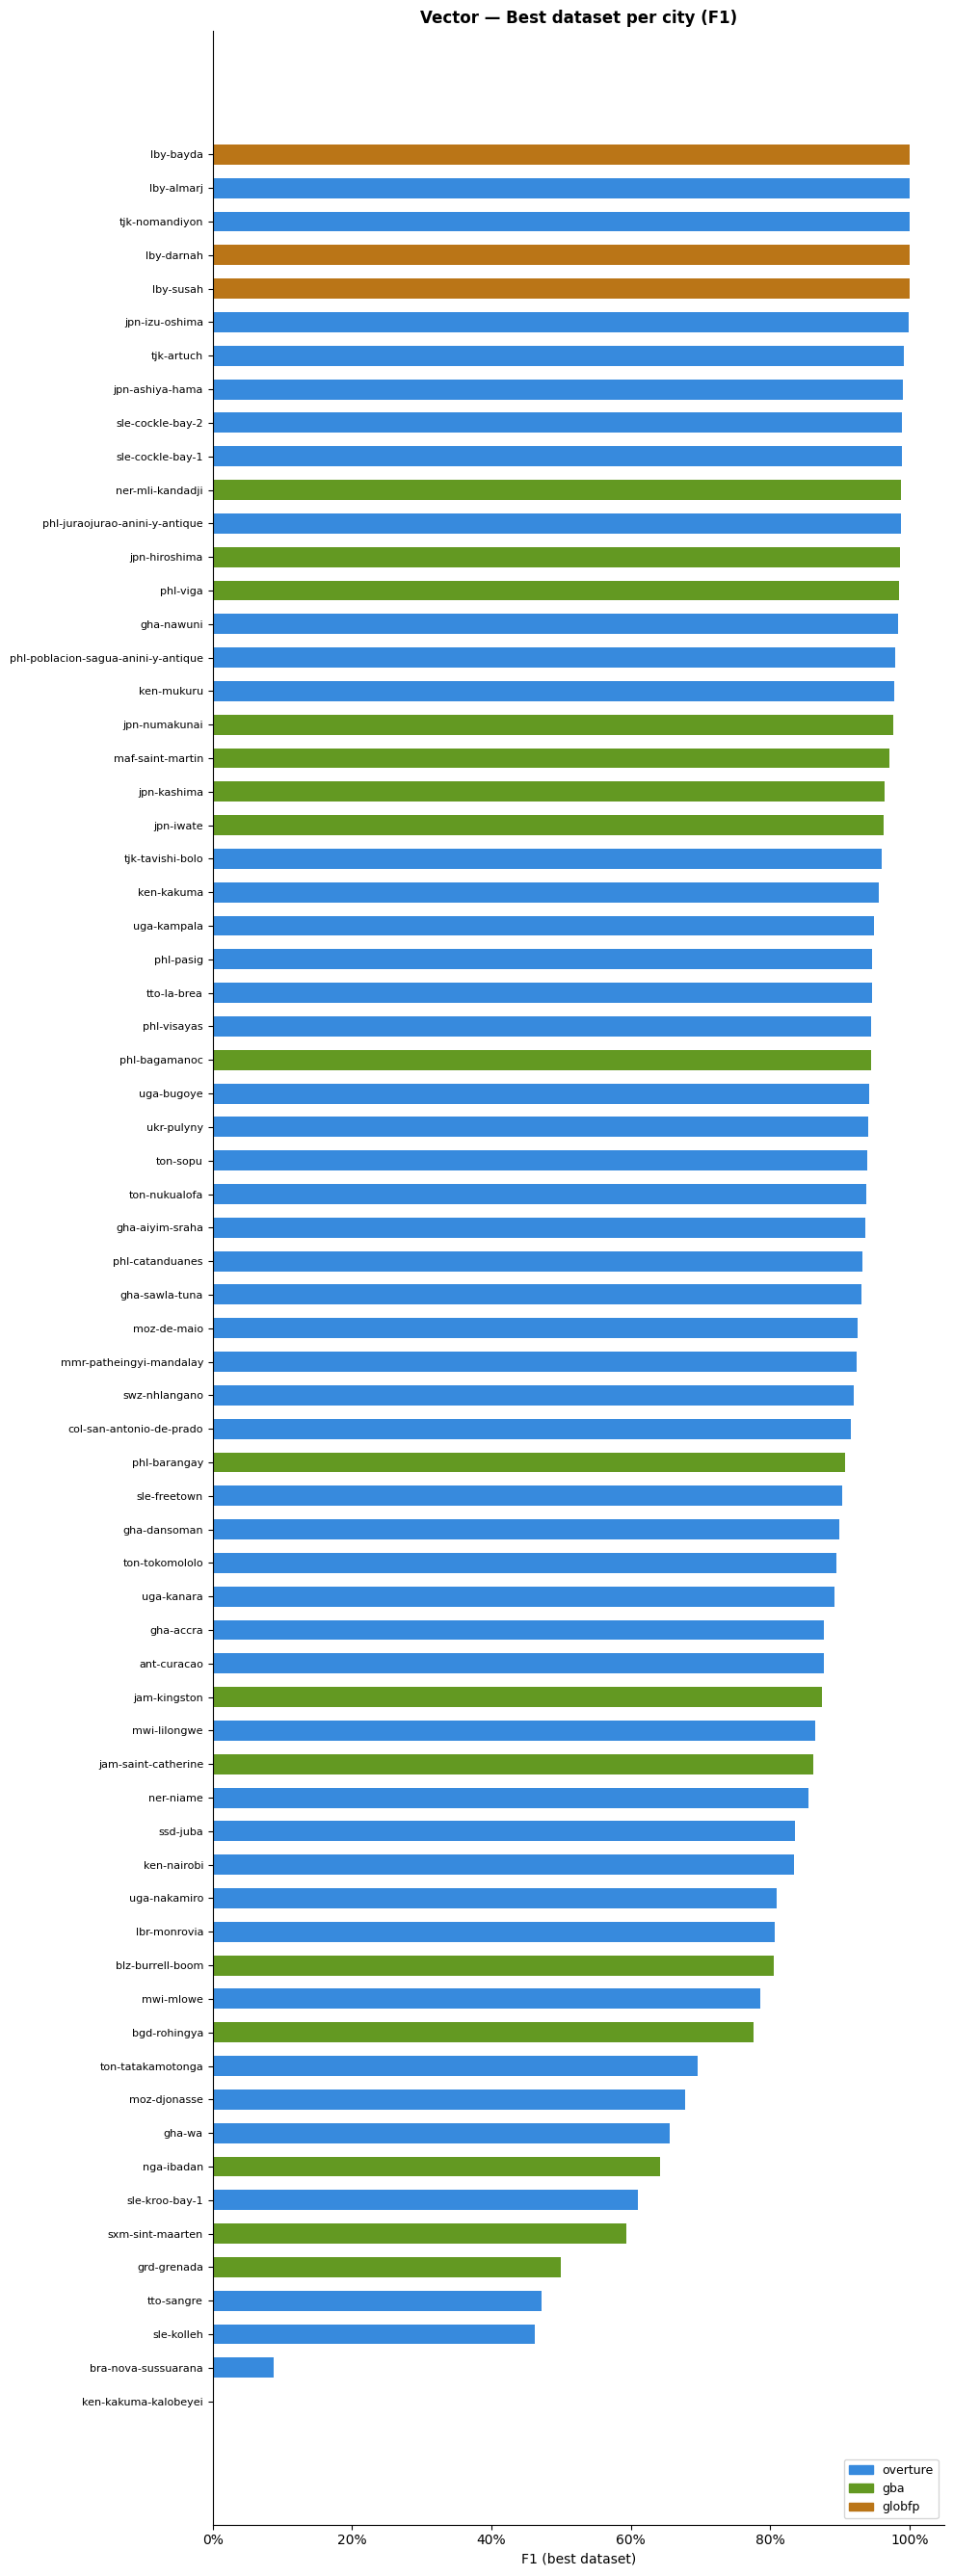

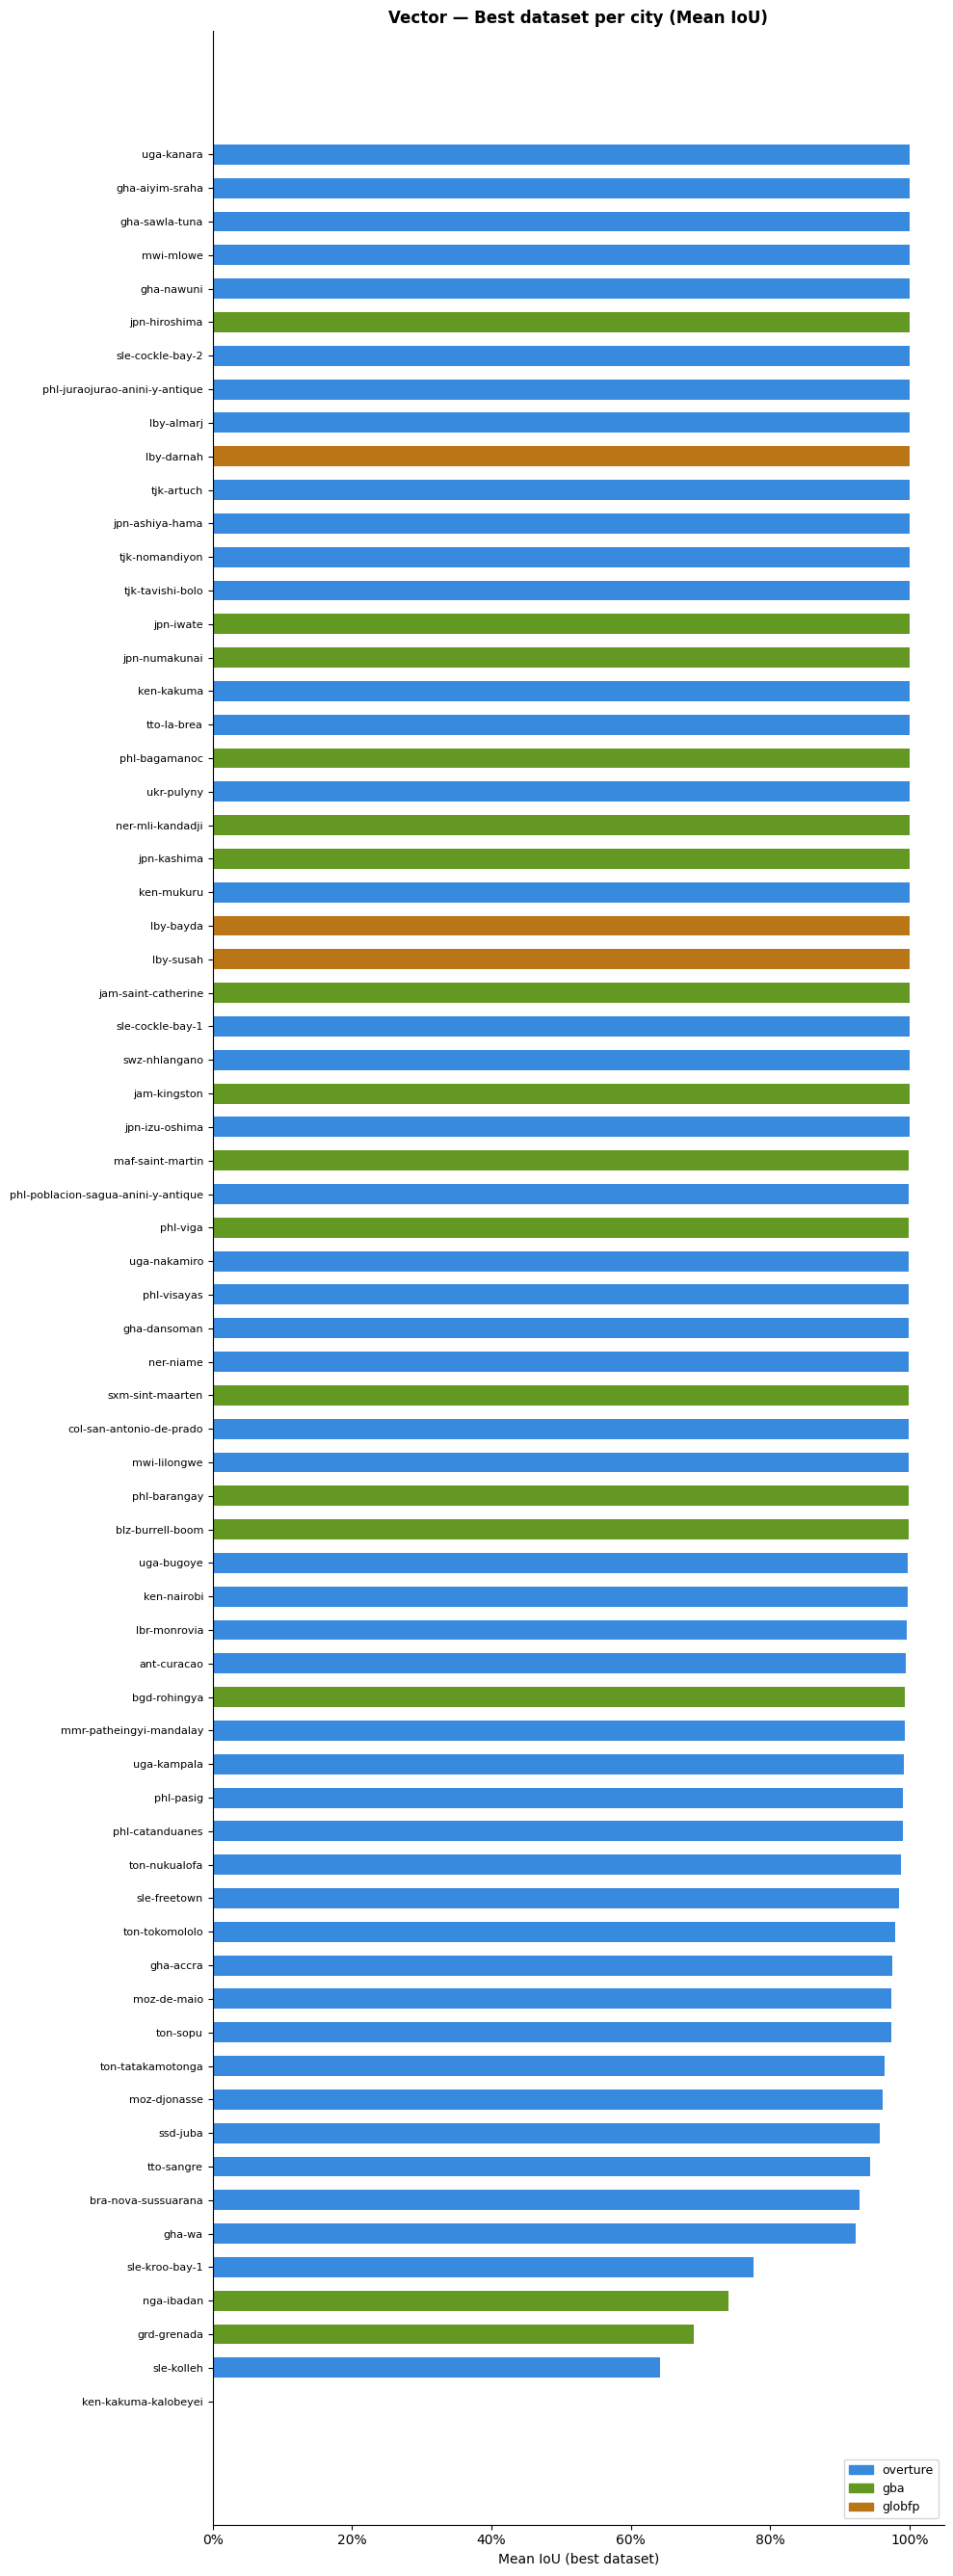

In [9]:
VEC_PALETTE = {"overture": "#378ADD", "gba": "#639922", "globfp": "#BA7517"}

def barh_best(df_best: pd.DataFrame, metric: str, palette: dict,
              xlabel: str, title: str) -> None:
    df_plot = df_best.sort_values(metric, ascending=True)
    colors  = df_plot["dataset"].map(palette).fillna("#999999")
    fig, ax = plt.subplots(figsize=(10, len(df_plot) * 0.38 + 1))
    ax.barh(df_plot["city"], df_plot[metric], color=colors, height=0.6)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    legend = [mpatches.Patch(color=c, label=ds) for ds, c in palette.items()
              if ds in df_plot["dataset"].values]
    ax.legend(handles=legend, loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.show()

df_vec_best = best_vector_per_city(df_vec)

barh_best(df_vec_best, "f1_city",   VEC_PALETTE, "F1 (best dataset)",         "Vector — Best dataset per city (F1)")
barh_best(df_vec_best, "iou_mean_tp", VEC_PALETTE, "Mean IoU (best dataset)", "Vector — Best dataset per city (Mean IoU)")

## 5. Vector — all datasets F1 comparison (grouped bar)

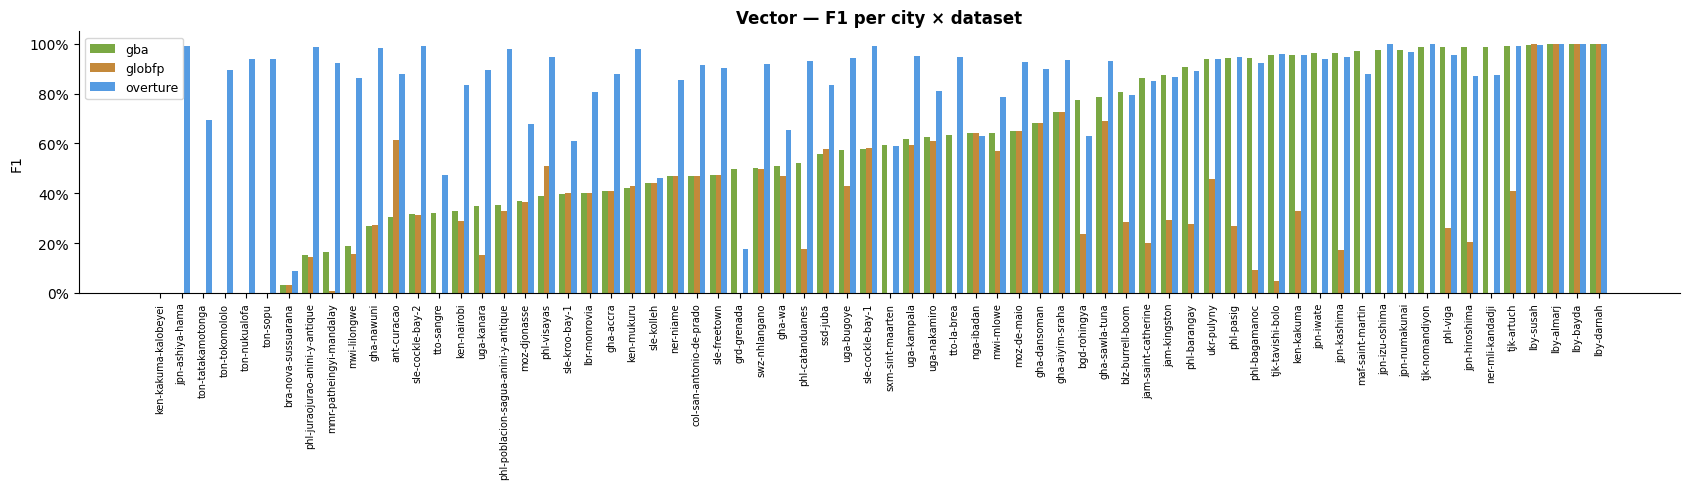

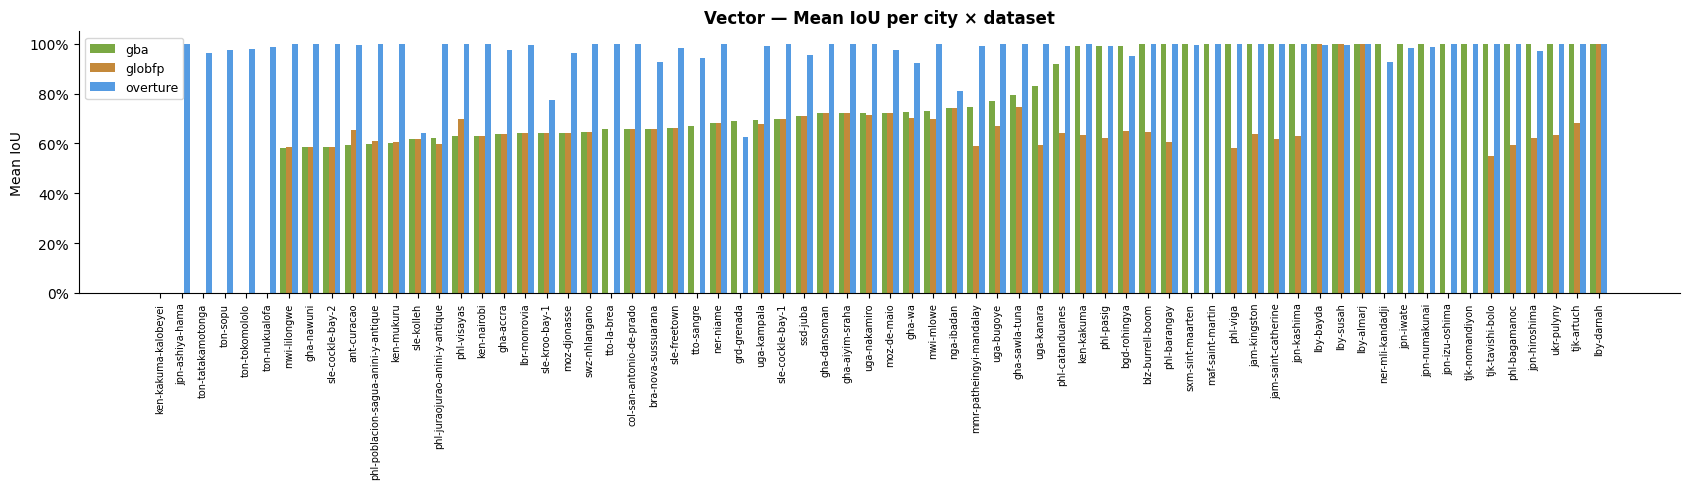

In [10]:
def grouped_bar_all(df: pd.DataFrame, metric: str, palette: dict,
                    ylabel: str, title: str) -> None:
    pivot = df.pivot(index="city", columns="dataset", values=metric).sort_values(
        df["dataset"].iloc[0] if df["dataset"].nunique() > 0 else metric, ascending=True
    )
    pivot = pivot.sort_values(list(pivot.columns), ascending=True)
    datasets = pivot.columns.tolist()
    cities   = pivot.index.tolist()
    n_ds, n_c = len(datasets), len(cities)
    x   = np.arange(n_c)
    w   = 0.8 / n_ds
    fig, ax = plt.subplots(figsize=(max(14, n_c * 0.25), 5))
    for i, ds in enumerate(datasets):
        color = palette.get(ds, f"C{i}")
        ax.bar(x + i * w - 0.4 + w / 2, pivot[ds].fillna(0), width=w,
               label=ds, color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=90, fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

grouped_bar_all(df_vec, "f1_city",    VEC_PALETTE, "F1",       "Vector — F1 per city × dataset")
grouped_bar_all(df_vec, "iou_mean_tp", VEC_PALETTE, "Mean IoU", "Vector — Mean IoU per city × dataset")

## 6. Raster — best dataset per city (area F1)

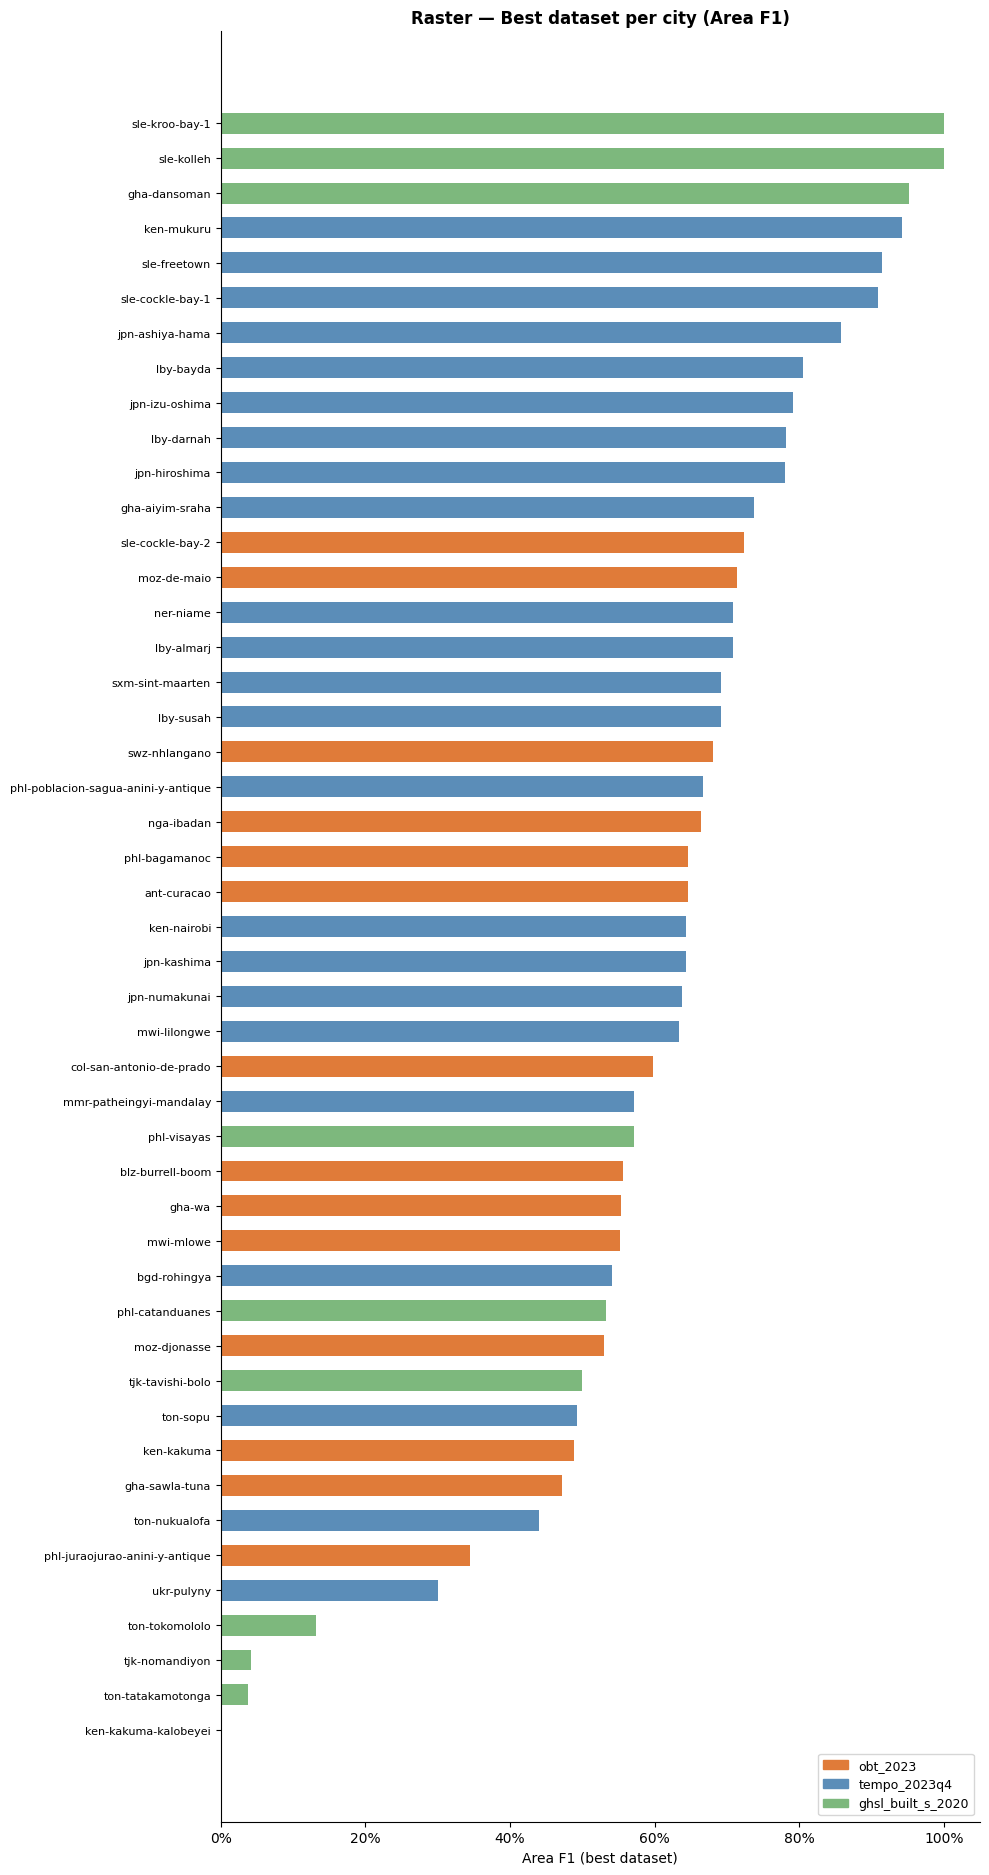

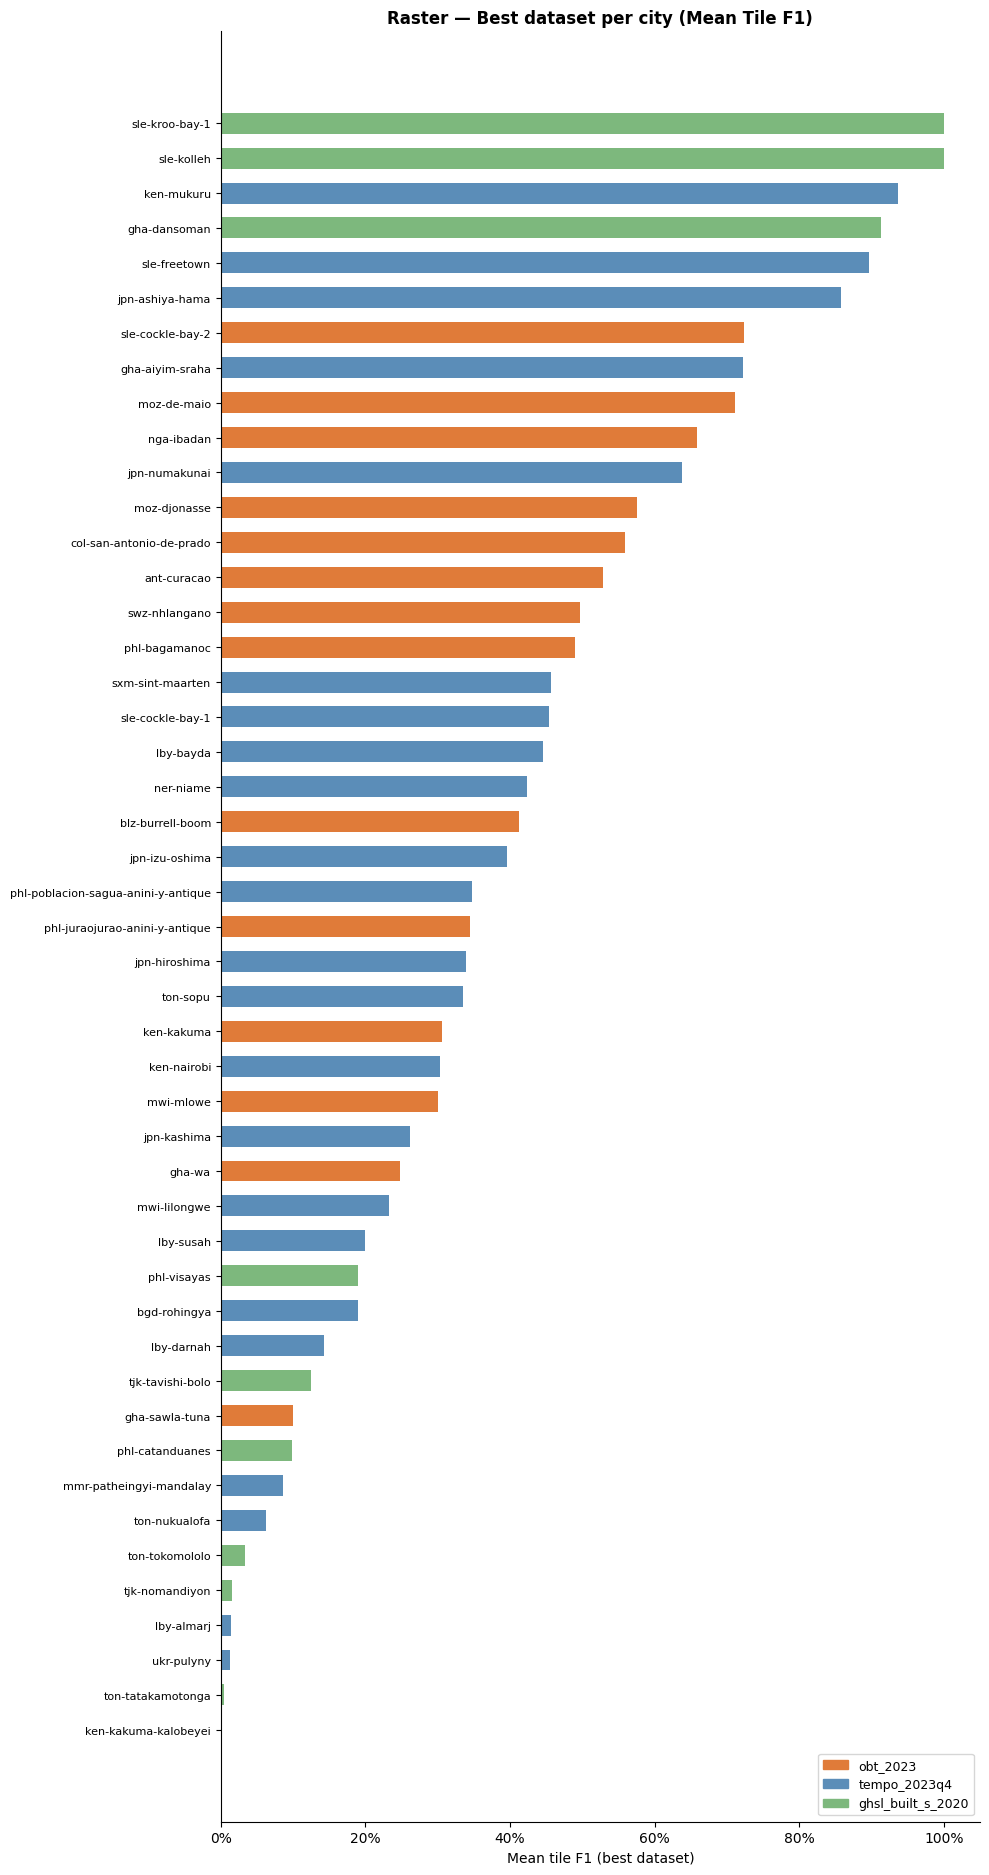

In [11]:
RAS_PALETTE = {"obt_2023": "#E07B39", "tempo_2023q4": "#5B8DB8", "ghsl_built_s_2020": "#7DB87D"}

# Normalise dataset names (underscore vs hyphen variations)
df_ras["dataset"] = df_ras["dataset"].str.replace("-", "_")

df_ras_best = best_raster_per_city(df_ras)

barh_best(df_ras_best, "f1_area",     RAS_PALETTE, "Area F1 (best dataset)",      "Raster — Best dataset per city (Area F1)")
barh_best(df_ras_best, "tile_f1_mean", RAS_PALETTE, "Mean tile F1 (best dataset)", "Raster — Best dataset per city (Mean Tile F1)")

## 7. Raster — all datasets area-F1 comparison

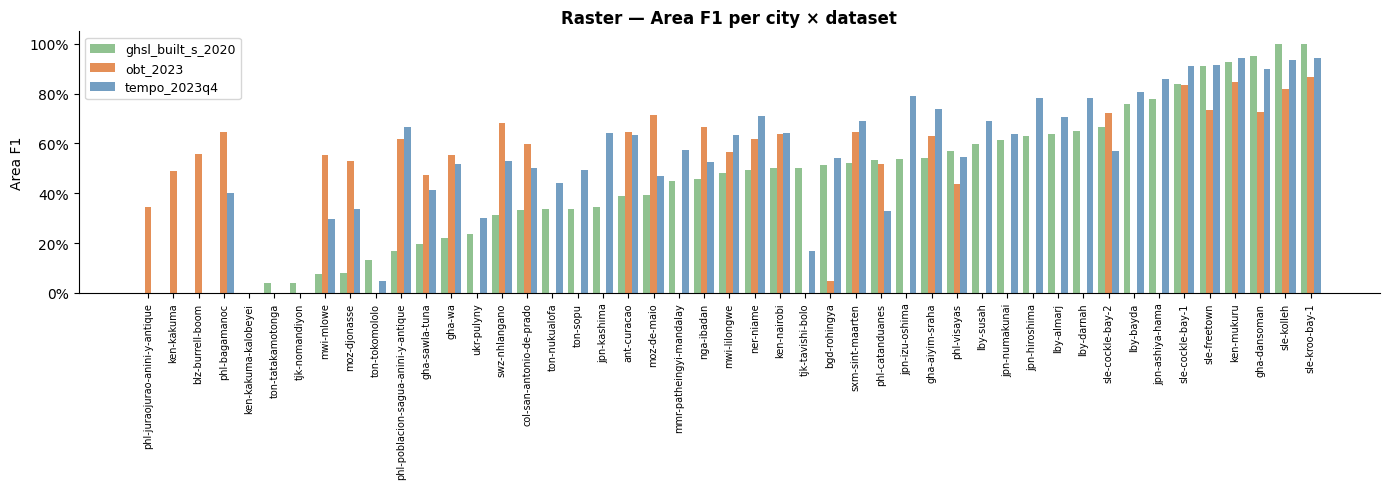

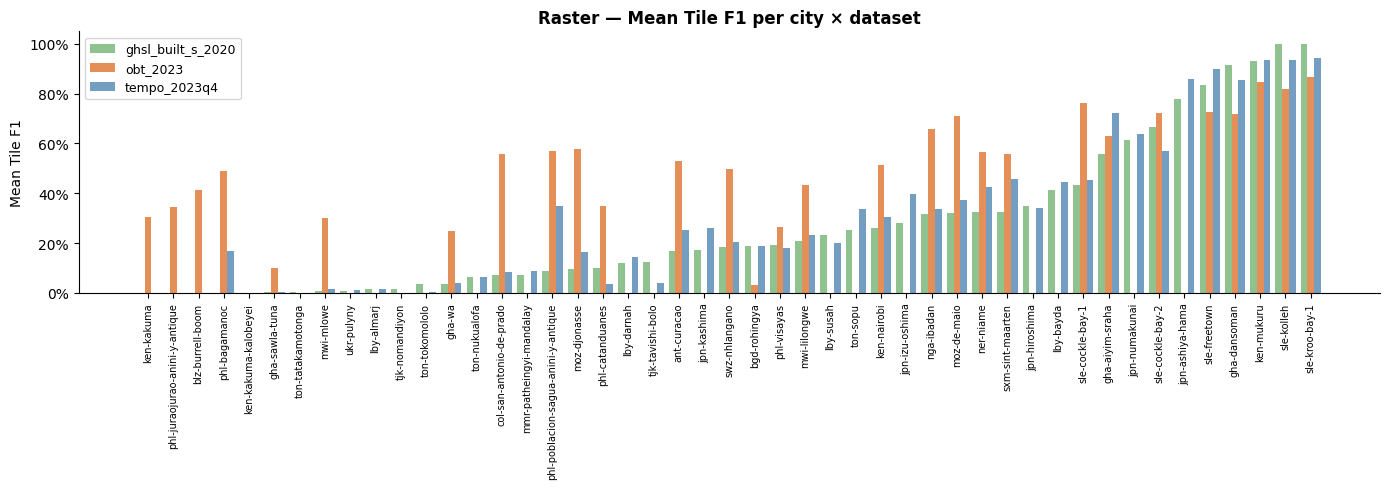

In [12]:
grouped_bar_all(df_ras, "f1_area",     RAS_PALETTE, "Area F1",      "Raster — Area F1 per city × dataset")
grouped_bar_all(df_ras, "tile_f1_mean", RAS_PALETTE, "Mean Tile F1", "Raster — Mean Tile F1 per city × dataset")

## 8. Global summary bar chart — vector vs raster side-by-side

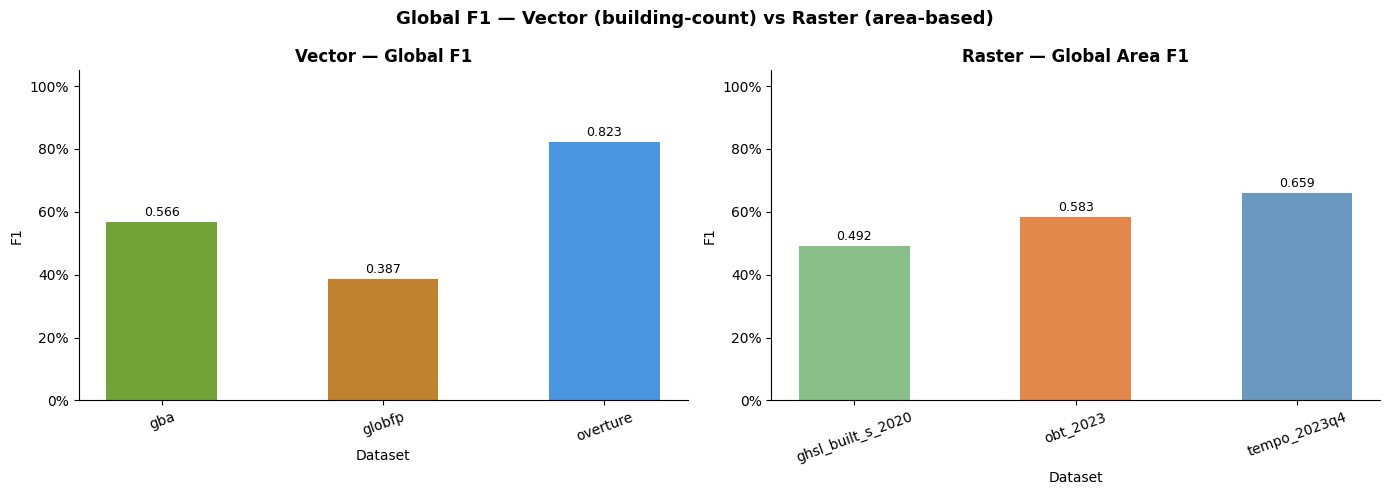

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df_g, palette, title, metric) in zip(
    axes,
    [
        (df_vec_global.reset_index(), VEC_PALETTE, "Vector — Global F1",      "f1_global"),
        (df_ras_global.reset_index(), RAS_PALETTE, "Raster — Global Area F1", "f1_global"),
    ],
):
    colors = df_g["dataset"].map(palette).fillna("#999999")
    ax.bar(df_g["dataset"], df_g[metric], color=colors, width=0.5, alpha=0.9)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("F1")
    ax.tick_params(axis="x", rotation=20)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(ax.patches, df_g[metric]):
        if np.isfinite(val):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Global F1 — Vector (building-count) vs Raster (area-based)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Relative area error — raster global (tile-level, weighted avg)

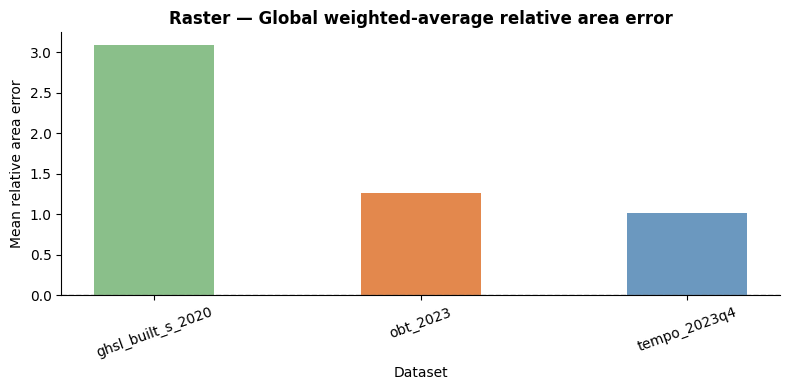

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
df_err = df_ras_global.reset_index()[["dataset", "rel_area_error_mean_wavg"]].dropna()
colors = df_err["dataset"].map(RAS_PALETTE).fillna("#999999")
ax.bar(df_err["dataset"], df_err["rel_area_error_mean_wavg"], color=colors, width=0.45, alpha=0.9)
ax.axhline(0, linestyle="--", linewidth=1, color="grey")
ax.set_title("Raster — Global weighted-average relative area error", fontweight="bold")
ax.set_xlabel("Dataset")
ax.set_ylabel("Mean relative area error")
ax.tick_params(axis="x", rotation=20)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Vector — IoU distribution across cities (violin)

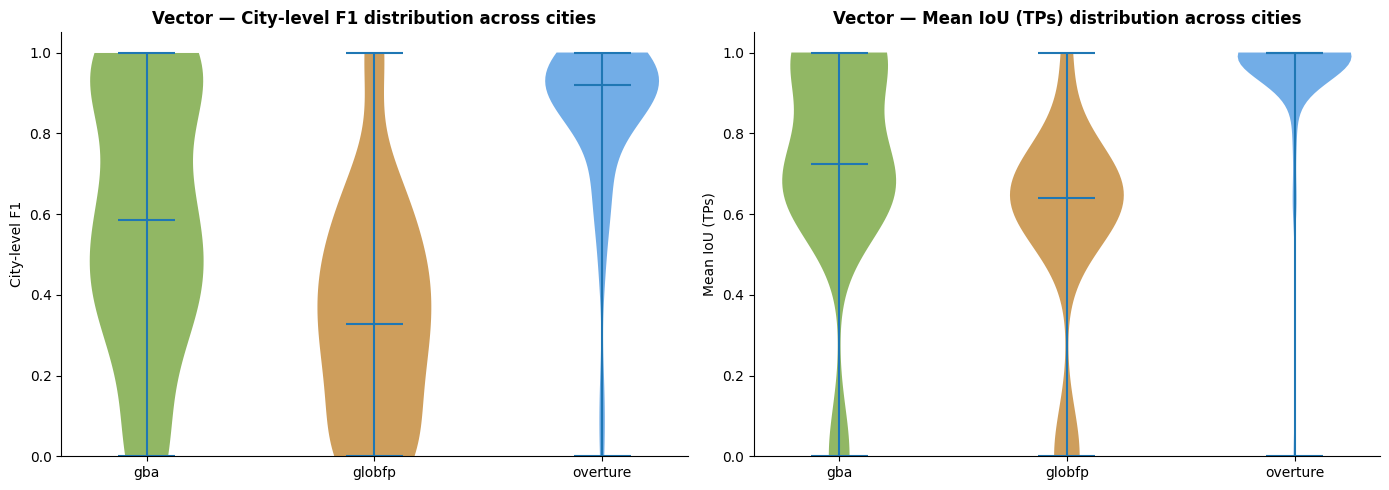

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, label) in zip(axes, [
    ("f1_city",    "City-level F1"),
    ("iou_mean_tp", "Mean IoU (TPs)"),
]):
    datasets_order = sorted(df_vec["dataset"].unique())
    data = [df_vec[df_vec["dataset"] == ds][metric].dropna().values for ds in datasets_order]
    parts = ax.violinplot(data, positions=range(len(datasets_order)), showmedians=True)
    for i, (pc, ds) in enumerate(zip(parts["bodies"], datasets_order)):
        pc.set_facecolor(VEC_PALETTE.get(ds, "#aaaaaa"))
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(datasets_order)))
    ax.set_xticklabels(datasets_order)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(label)
    ax.set_title(f"Vector — {label} distribution across cities", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 11. Raster — tile F1 distribution across cities (violin)

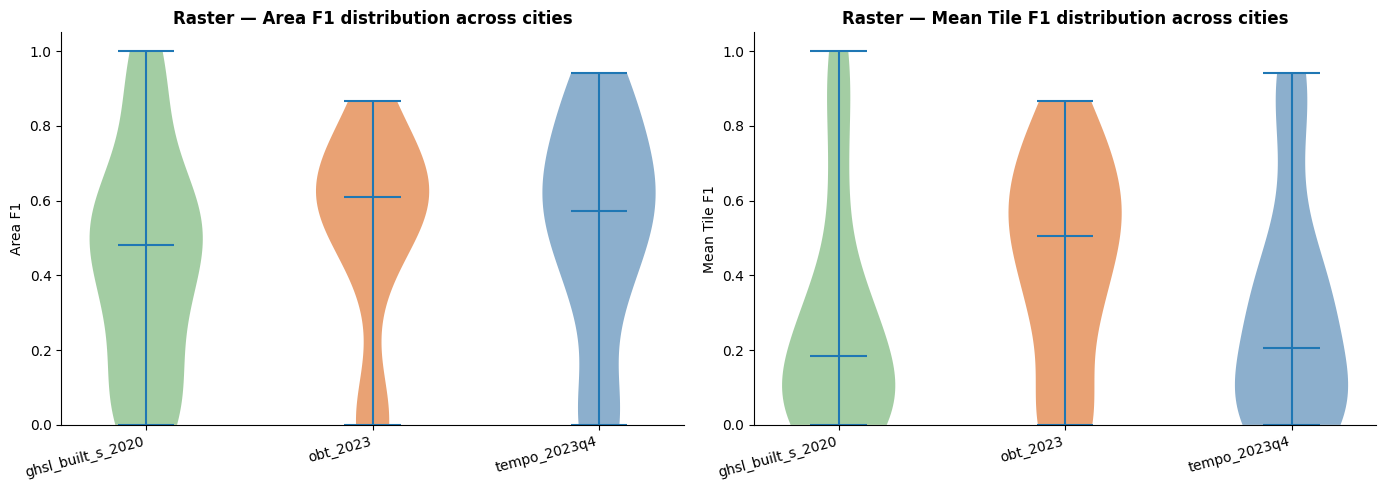

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, label) in zip(axes, [
    ("f1_area",     "Area F1"),
    ("tile_f1_mean", "Mean Tile F1"),
]):
    datasets_order = sorted(df_ras["dataset"].unique())
    data = [df_ras[df_ras["dataset"] == ds][metric].dropna().values for ds in datasets_order]
    parts = ax.violinplot(data, positions=range(len(datasets_order)), showmedians=True)
    for i, (pc, ds) in enumerate(zip(parts["bodies"], datasets_order)):
        pc.set_facecolor(RAS_PALETTE.get(ds, "#aaaaaa"))
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(datasets_order)))
    ax.set_xticklabels(datasets_order, rotation=15, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(label)
    ax.set_title(f"Raster — {label} distribution across cities", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()